# Data Inspection

## Objective
Validate dataset structure, completeness, identifiers, hierarchy, variable types.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 100)

DATA_PATH = Path("./semiconductor_yield.csv")

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset loaded successfully.
Rows:    1,250
Columns: 28


## Factor Structure
Examine how product, technology node, and tool assignments overlap. These checks help identify confounding before inferential modeling.


In [3]:
import pandas as pd
from itertools import combinations

factors = ["product_type", "technology_node",
           "etch_tool", "litho_tool", "deposition_tool", "implant_tool"]

crosstabs = {(a, b): pd.crosstab(df[a], df[b], margins=True)
             for a, b in combinations(factors, 2)}

In [4]:
for (a, b), ct in crosstabs.items():
    print(f"\n=== {a} x {b} ===")
    print(ct)


=== product_type x technology_node ===
technology_node  10nm  14nm  22nm  28nm  7nm   All
product_type                                      
ASIC               50    75    25    50    0   200
CPU               150    75     0     0   50   275
FPGA               25    25    50    75  100   275
GPU                50    50    25   100   50   275
Memory            100    25    25    75    0   225
All               375   250   125   300  200  1250

=== product_type x etch_tool ===
etch_tool     ETCH_01  ETCH_02  ETCH_03  ETCH_04  ETCH_05   All
product_type                                                   
ASIC               50        0       25       75       50   200
CPU                25       50       50      125       25   275
FPGA              100      125       50        0        0   275
GPU                25       50       25       75      100   275
Memory             25       75       75       25       25   225
All               225      300      225      300      200  1250

=== p

In [5]:
def cramers_v_corrected(a, b):
    ct = pd.crosstab(a, b)
    chi2 = chi2_contingency(ct)[0]
    n, r, k = ct.values.sum(), *ct.shape
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    r_, k_ = r - (r - 1)**2 / (n - 1), k - (k - 1)**2 / (n - 1)
    return np.sqrt(phi2 / (min(r_, k_) - 1))

v = pd.DataFrame(index=factors, columns=factors, dtype=float)
for a, b in combinations(factors, 2):
    v.loc[a, b] = v.loc[b, a] = cramers_v_corrected(df[a], df[b])
print(v.round(2))

                 product_type  technology_node  etch_tool  litho_tool  deposition_tool  implant_tool
product_type              NaN             0.30       0.32        0.25             0.26          0.31
technology_node          0.30              NaN       0.32        0.30             0.37          0.32
etch_tool                0.32             0.32        NaN        0.30             0.28          0.25
litho_tool               0.25             0.30       0.30         NaN             0.31          0.21
deposition_tool          0.26             0.37       0.28        0.31              NaN          0.24
implant_tool             0.31             0.32       0.25        0.21             0.24           NaN


In [6]:
for a, b in combinations(factors, 2):
    chi2, p, dof, expected = chi2_contingency(pd.crosstab(df[a], df[b]))
    print(f"{a} x {b}: p={p:.3g}, cells with expected<5: {(expected < 5).mean():.0%}")

product_type x technology_node: p=5.3e-90, cells with expected<5: 0%
product_type x etch_tool: p=6.78e-104, cells with expected<5: 0%
product_type x litho_tool: p=5.8e-47, cells with expected<5: 0%
product_type x deposition_tool: p=1.08e-34, cells with expected<5: 0%
product_type x implant_tool: p=8.35e-49, cells with expected<5: 0%
technology_node x etch_tool: p=7.22e-103, cells with expected<5: 0%
technology_node x litho_tool: p=1.08e-67, cells with expected<5: 0%
technology_node x deposition_tool: p=3.63e-70, cells with expected<5: 0%
technology_node x implant_tool: p=9.18e-54, cells with expected<5: 0%
etch_tool x litho_tool: p=2.92e-69, cells with expected<5: 0%
etch_tool x deposition_tool: p=2.54e-38, cells with expected<5: 0%
etch_tool x implant_tool: p=2.38e-32, cells with expected<5: 0%
litho_tool x deposition_tool: p=2.67e-51, cells with expected<5: 0%
litho_tool x implant_tool: p=1.56e-22, cells with expected<5: 0%
deposition_tool x implant_tool: p=2.32e-31, cells with expec

In [7]:
df.tail()

,lot_id,wafer_id,product_type,technology_node,process_date,etch_tool,litho_tool,deposition_tool,implant_tool,etch_rate,pressure,temperature,exposure_time,focus_offset,dose,deposition_rate,thickness_uniformity,implant_energy,tilt_angle,critical_dimension,oxide_thickness,resistivity,defect_count,defect_density,vth,leakage_current,resistance,yield
1245,LOT_0050,W021,Memory,10nm,2023-02-19,ETCH_03,LITHO_04,DEP_01,IMP_03,3.512247,153.012725,68.810823,1.537327,0.035177,9.991627e+14,1.642863,2.060751,50.553752,7.028695,21.649794,53.730871,2.500152,802,1.147964,0.603979,0.000422,89.863144,0.434268
1246,LOT_0050,W022,Memory,10nm,2023-02-19,ETCH_03,LITHO_04,DEP_01,IMP_03,3.723822,148.911210,69.623432,1.525331,0.039904,9.998745e+14,1.734080,1.990384,50.010052,6.663984,20.136202,54.157854,2.382416,812,1.115144,0.554266,0.000388,104.234782,0.566107
1247,LOT_0050,W023,Memory,10nm,2023-02-19,ETCH_03,LITHO_04,DEP_01,IMP_03,3.752730,151.063318,69.204973,1.554961,0.042586,1.007722e+15,1.727280,1.777337,48.238493,7.338597,22.715463,47.904676,2.446836,719,1.009962,0.659628,0.000377,92.526484,0.442415
1248,LOT_0050,W024,Memory,10nm,2023-02-19,ETCH_03,LITHO_04,DEP_01,IMP_03,3.770138,147.066408,67.337698,1.446774,0.040153,1.002290e+15,1.756986,1.877789,50.720163,7.115463,22.240933,56.431227,2.421408,740,1.058971,0.542010,0.000153,89.531757,0.782406
1249,LOT_0050,W025,Memory,10nm,2023-02-19,ETCH_03,LITHO_04,DEP_01,IMP_03,3.733854,161.662549,69.717739,1.445642,0.040875,9.866302e+14,1.823804,1.969207,49.270510,7.115036,22.696109,54.605384,2.267763,795,1.105041,0.613305,0.000141,102.238941,0.666890


## Schema and Data Quality
Review column names, data types, duplicates, identifiers, categorical values, missingness, and cardinality.


In [8]:
# Inspect column names
for i, col in enumerate(df.columns, start=1):
    print(f"{i:3}. {col}")

  1. lot_id
  2. wafer_id
  3. product_type
  4. technology_node
  5. process_date
  6. etch_tool
  7. litho_tool
  8. deposition_tool
  9. implant_tool
 10. etch_rate
 11. pressure
 12. temperature
 13. exposure_time
 14. focus_offset
 15. dose
 16. deposition_rate
 17. thickness_uniformity
 18. implant_energy
 19. tilt_angle
 20. critical_dimension
 21. oxide_thickness
 22. resistivity
 23. defect_count
 24. defect_density
 25. vth
 26. leakage_current
 27. resistance
 28. yield


In [9]:
df.dtypes

lot_id                   object
wafer_id                 object
product_type             object
technology_node          object
process_date             object
etch_tool                object
litho_tool               object
deposition_tool          object
implant_tool             object
etch_rate               float64
pressure                float64
temperature             float64
exposure_time           float64
focus_offset            float64
dose                    float64
deposition_rate         float64
thickness_uniformity    float64
implant_energy          float64
tilt_angle              float64
critical_dimension      float64
oxide_thickness         float64
resistivity             float64
defect_count              int64
defect_density          float64
vth                     float64
leakage_current         float64
resistance              float64
yield                   float64
dtype: object

In [10]:
# Summarize data types
df.dtypes.value_counts()

float64    18
object      9
int64       1
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   lot_id                1250 non-null   object 
 1   wafer_id              1250 non-null   object 
 2   product_type          1250 non-null   object 
 3   technology_node       1250 non-null   object 
 4   process_date          1250 non-null   object 
 5   etch_tool             1250 non-null   object 
 6   litho_tool            1250 non-null   object 
 7   deposition_tool       1250 non-null   object 
 8   implant_tool          1250 non-null   object 
 9   etch_rate             1250 non-null   float64
 10  pressure              1250 non-null   float64
 11  temperature           1250 non-null   float64
 12  exposure_time         1250 non-null   float64
 13  focus_offset          1250 non-null   float64
 14  dose                  1250 non-null   float64
 15  deposition_rate      

In [12]:
# Check exact duplicate rows
duplicate_rows = df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_rows:,}")
print(f"Duplicate percentage: {duplicate_rows / len(df) * 100:.2f}%")

Exact duplicate rows: 0
Duplicate percentage: 0.00%


In [13]:
id_candidates = [
    col for col in df.columns
    if (
        col.lower().endswith("_id")
        or col.lower().startswith("id_")
        or "wafer_id" in col.lower()
        or "lot_id" in col.lower()
        or "batch_id" in col.lower()
        or "tool" in col.lower()
        or "equipment" in col.lower()
        or "machine" in col.lower()
    )
]

id_candidates



['lot_id',
 'wafer_id',
 'etch_tool',
 'litho_tool',
 'deposition_tool',
 'implant_tool']

In [14]:
for col in id_candidates:
    print(
        f"{col:30} "
        f"unique={df[col].nunique(dropna=True):,} "
        f"missing={df[col].isna().sum():,}"
    )

lot_id                         unique=50 missing=0
wafer_id                       unique=25 missing=0
etch_tool                      unique=5 missing=0
litho_tool                     unique=4 missing=0
deposition_tool                unique=3 missing=0
implant_tool                   unique=3 missing=0


In [15]:
WAFER_ID = "wafer_id"

df[WAFER_ID].nunique(dropna=False)


25

In [16]:
print(f"Rows:             {len(df):,}")
print(f"Unique wafer IDs: {df[WAFER_ID].nunique():,}")
print(f"Missing IDs:      {df[WAFER_ID].isna().sum():,}")
print(f"Duplicated IDs:   {df[WAFER_ID].duplicated().sum():,}")

Rows:             1,250
Unique wafer IDs: 25
Missing IDs:      0
Duplicated IDs:   1,225


In [17]:
categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

categorical_cols


['lot_id',
 'wafer_id',
 'product_type',
 'technology_node',
 'process_date',
 'etch_tool',
 'litho_tool',
 'deposition_tool',
 'implant_tool']

In [18]:
# Inspect categorical values
for col in categorical_cols:
    print("=" * 70)
    print(col)
    print(f"Unique values: {df[col].nunique(dropna=False)}")
    print(df[col].value_counts(dropna=False).head(20))
    print()

lot_id
Unique values: 50
LOT_0001    25
LOT_0038    25
LOT_0028    25
LOT_0029    25
LOT_0030    25
LOT_0031    25
LOT_0032    25
LOT_0033    25
LOT_0034    25
LOT_0035    25
LOT_0036    25
LOT_0037    25
LOT_0039    25
LOT_0002    25
LOT_0040    25
LOT_0041    25
LOT_0042    25
LOT_0043    25
LOT_0044    25
LOT_0045    25
Name: lot_id, dtype: int64

wafer_id
Unique values: 25
W001    50
W014    50
W024    50
W023    50
W022    50
W021    50
W020    50
W019    50
W018    50
W017    50
W016    50
W015    50
W013    50
W002    50
W012    50
W011    50
W010    50
W009    50
W008    50
W007    50
Name: wafer_id, dtype: int64

product_type
Unique values: 5
CPU       275
FPGA      275
GPU       275
Memory    225
ASIC      200
Name: product_type, dtype: int64

technology_node
Unique values: 5
10nm    375
28nm    300
14nm    250
7nm     200
22nm    125
Name: technology_node, dtype: int64

process_date
Unique values: 50
2023-01-01    25
2023-02-07    25
2023-01-28    25
2023-01-29    25
2023-01

## Manufacturing Hierarchy
Confirm the sampling structure and determine which variables are fixed at the lot level versus varying among wafers within a lot.


In [19]:


wafers_per_lot = (
    df.groupby("lot_id")["wafer_id"]
      .nunique()
)

print(wafers_per_lot.describe())

print("\nDistribution of wafer counts per lot:")
print(wafers_per_lot.value_counts().sort_index())

count    50.0
mean     25.0
std       0.0
min      25.0
25%      25.0
50%      25.0
75%      25.0
max      25.0
Name: wafer_id, dtype: float64

Distribution of wafer counts per lot:
25    50
Name: wafer_id, dtype: int64


In [20]:
# Verify lot-level product and technology assignments
lot_context = (
    df.groupby("lot_id")
      .agg(
          wafer_count=("wafer_id", "nunique"),
          product_type_count=("product_type", "nunique"),
          technology_node_count=("technology_node", "nunique"),
          process_date_count=("process_date", "nunique")
      )
)

lot_context.head(10)

,wafer_count,product_type_count,technology_node_count,process_date_count
lot_id,,,,
LOT_0001,25,1,1,1
LOT_0002,25,1,1,1
LOT_0003,25,1,1,1
LOT_0004,25,1,1,1
LOT_0005,25,1,1,1
LOT_0006,25,1,1,1
LOT_0007,25,1,1,1
LOT_0008,25,1,1,1
LOT_0009,25,1,1,1


In [21]:
print("Lots containing multiple product types:")
print((lot_context["product_type_count"] > 1).sum())

print("\nLots containing multiple technology nodes:")
print((lot_context["technology_node_count"] > 1).sum())

print("\nLots containing multiple process dates:")
print((lot_context["process_date_count"] > 1).sum())

Lots containing multiple product types:
0

Lots containing multiple technology nodes:
0

Lots containing multiple process dates:
0


In [22]:
# Verify whether tool assignments are lot-level
tool_variation = (
    df.groupby("lot_id")
      .agg(
          etch_tools=("etch_tool", "nunique"),
          litho_tools=("litho_tool", "nunique"),
          deposition_tools=("deposition_tool", "nunique"),
          implant_tools=("implant_tool", "nunique")
      )
)

tool_variation.describe()

,etch_tools,litho_tools,deposition_tools,implant_tools
count,50.0,50.0,50.0,50.0
mean,1.0,1.0,1.0,1.0
std,0.0,0.0,0.0,0.0
min,1.0,1.0,1.0,1.0
25%,1.0,1.0,1.0,1.0
50%,1.0,1.0,1.0,1.0
75%,1.0,1.0,1.0,1.0
max,1.0,1.0,1.0,1.0


In [23]:
for col in tool_variation.columns:
    print(f"\n{col}")
    print(tool_variation[col].value_counts().sort_index())


etch_tools
1    50
Name: etch_tools, dtype: int64

litho_tools
1    50
Name: litho_tools, dtype: int64

deposition_tools
1    50
Name: deposition_tools, dtype: int64

implant_tools
1    50
Name: implant_tools, dtype: int64


## Numeric and Date Checks
Summarize numeric ranges and distributions, then validate the process date field.


In [25]:
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_summary = df[numeric_cols].describe().T

numeric_summary = df[numeric_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

numeric_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
etch_rate,1250.0,3.615159e+00,1.002148e-01,3.304931e+00,3.389645e+00,3.455504e+00,3.544830e+00,3.612966e+00,3.681864e+00,3.780090e+00,3.846192e+00,3.935599e+00
pressure,1250.0,1.527010e+02,5.147463e+00,1.352929e+02,1.407359e+02,1.444074e+02,1.492328e+02,1.526543e+02,1.561602e+02,1.613649e+02,1.647310e+02,1.683429e+02
temperature,1250.0,6.676968e+01,2.193719e+00,6.032850e+01,6.177661e+01,6.312198e+01,6.526426e+01,6.672246e+01,6.828645e+01,7.041982e+01,7.145814e+01,7.317197e+01
exposure_time,1250.0,1.501329e+00,4.989396e-02,1.350315e+00,1.379489e+00,1.418879e+00,1.467451e+00,1.501331e+00,1.534600e+00,1.581328e+00,1.608187e+00,1.670403e+00
focus_offset,1250.0,2.744612e-02,6.699731e-03,8.576942e-03,1.310772e-02,1.683453e-02,2.293009e-02,2.697452e-02,3.188992e-02,3.904138e-02,4.413992e-02,5.146789e-02
dose,1250.0,1.000095e+15,9.896583e+12,9.703325e+14,9.783735e+14,9.838399e+14,9.930979e+14,9.999683e+14,1.006631e+15,1.017061e+15,1.023352e+15,1.033010e+15
deposition_rate,1250.0,1.899942e+00,1.164870e-01,1.542779e+00,1.625451e+00,1.707062e+00,1.827348e+00,1.900440e+00,1.979659e+00,2.093579e+00,2.158083e+00,2.259813e+00
thickness_uniformity,1250.0,1.702233e+00,2.369053e-01,8.750489e-01,1.179843e+00,1.323339e+00,1.534593e+00,1.700894e+00,1.864622e+00,2.090662e+00,2.262643e+00,2.456949e+00
implant_energy,1250.0,4.998678e+01,9.987411e-01,4.704575e+01,4.760259e+01,4.838493e+01,4.928990e+01,4.997552e+01,5.068404e+01,5.165479e+01,5.220235e+01,5.380672e+01
tilt_angle,1250.0,7.001714e+00,4.980586e-01,5.462945e+00,5.899604e+00,6.166158e+00,6.667923e+00,7.000520e+00,7.344025e+00,7.813971e+00,8.177858e+00,8.471524e+00


In [26]:
numeric_summary = df[numeric_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

numeric_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
etch_rate,1250.0,3.615159e+00,1.002148e-01,3.304931e+00,3.389645e+00,3.455504e+00,3.544830e+00,3.612966e+00,3.681864e+00,3.780090e+00,3.846192e+00,3.935599e+00
pressure,1250.0,1.527010e+02,5.147463e+00,1.352929e+02,1.407359e+02,1.444074e+02,1.492328e+02,1.526543e+02,1.561602e+02,1.613649e+02,1.647310e+02,1.683429e+02
temperature,1250.0,6.676968e+01,2.193719e+00,6.032850e+01,6.177661e+01,6.312198e+01,6.526426e+01,6.672246e+01,6.828645e+01,7.041982e+01,7.145814e+01,7.317197e+01
exposure_time,1250.0,1.501329e+00,4.989396e-02,1.350315e+00,1.379489e+00,1.418879e+00,1.467451e+00,1.501331e+00,1.534600e+00,1.581328e+00,1.608187e+00,1.670403e+00
focus_offset,1250.0,2.744612e-02,6.699731e-03,8.576942e-03,1.310772e-02,1.683453e-02,2.293009e-02,2.697452e-02,3.188992e-02,3.904138e-02,4.413992e-02,5.146789e-02
dose,1250.0,1.000095e+15,9.896583e+12,9.703325e+14,9.783735e+14,9.838399e+14,9.930979e+14,9.999683e+14,1.006631e+15,1.017061e+15,1.023352e+15,1.033010e+15
deposition_rate,1250.0,1.899942e+00,1.164870e-01,1.542779e+00,1.625451e+00,1.707062e+00,1.827348e+00,1.900440e+00,1.979659e+00,2.093579e+00,2.158083e+00,2.259813e+00
thickness_uniformity,1250.0,1.702233e+00,2.369053e-01,8.750489e-01,1.179843e+00,1.323339e+00,1.534593e+00,1.700894e+00,1.864622e+00,2.090662e+00,2.262643e+00,2.456949e+00
implant_energy,1250.0,4.998678e+01,9.987411e-01,4.704575e+01,4.760259e+01,4.838493e+01,4.928990e+01,4.997552e+01,5.068404e+01,5.165479e+01,5.220235e+01,5.380672e+01
tilt_angle,1250.0,7.001714e+00,4.980586e-01,5.462945e+00,5.899604e+00,6.166158e+00,6.667923e+00,7.000520e+00,7.344025e+00,7.813971e+00,8.177858e+00,8.471524e+00


In [27]:
# Check missing values
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
})

missing = missing.sort_values("missing_pct", ascending=False)

missing[missing["missing_count"] > 0]

,missing_count,missing_pct


In [28]:
# Inspect unusually frequent numeric values

for col in numeric_cols:
    counts = df[col].value_counts(dropna=False).head(5)

    print("=" * 60)
    print(col)
    print(counts)

etch_rate
3.559737    1
3.521074    1
3.617338    1
3.567846    1
3.689613    1
Name: etch_rate, dtype: int64
pressure
149.808678    1
150.997034    1
140.972096    1
156.644246    1
153.062425    1
Name: pressure, dtype: int64
temperature
66.595377    1
64.560895    1
62.748551    1
65.036498    1
62.342437    1
Name: temperature, dtype: int64
exposure_time
1.576151    1
1.423291    1
1.606458    1
1.433388    1
1.483705    1
Name: exposure_time, dtype: int64
focus_offset
0.019829    1
0.044642    1
0.031732    1
0.024913    1
0.041874    1
Name: focus_offset, dtype: int64
dose
1.005426e+15    1
1.000978e+15    1
1.004891e+15    1
1.006291e+15    1
9.978430e+14    1
Name: dose, dtype: int64
deposition_rate
2.147921    1
1.878146    1
1.870850    1
1.907781    1
1.992699    1
Name: deposition_rate, dtype: int64
thickness_uniformity
1.673487    1
1.425594    1
1.743686    1
2.075384    1
1.588675    1
Name: thickness_uniformity, dtype: int64
implant_energy
49.530526    1
48.002953    1


In [29]:
# Check for constant variables

constant_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

constant_cols

[]

In [30]:
# Check for near-constant variables

near_constant = []

for col in df.columns:
    freq = df[col].value_counts(
        normalize=True,
        dropna=False
    )

    if len(freq) > 0 and freq.iloc[0] >= 0.95:
        near_constant.append({
            "column": col,
            "dominant_value": freq.index[0],
            "dominant_pct": freq.iloc[0] * 100
        })

pd.DataFrame(near_constant, columns=["column", "dominant_value", "dominant_pct"]) \
    .sort_values("dominant_pct", ascending=False)

,column,dominant_value,dominant_pct


In [31]:
# Check variable cardinality
cardinality = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "unique_count": [df[c].nunique(dropna=False) for c in df.columns],
    "unique_pct": [
        df[c].nunique(dropna=False) / len(df) * 100
        for c in df.columns
    ]
})

cardinality.sort_values("unique_count")

,column,dtype,unique_count,unique_pct
8,implant_tool,object,3,0.24
7,deposition_tool,object,3,0.24
6,litho_tool,object,4,0.32
2,product_type,object,5,0.40
3,technology_node,object,5,0.40
5,etch_tool,object,5,0.40
1,wafer_id,object,25,2.00
0,lot_id,object,50,4.00
4,process_date,object,50,4.00
22,defect_count,int64,359,28.72


In [32]:
# Inspect dates and timestamps

date_candidates = [
    col for col in df.columns
    if any(term in col.lower() for term in
           ["date", "time", "timestamp", "start", "end"])
]

date_candidates

['process_date', 'exposure_time']

In [33]:
process_date_parsed = pd.to_datetime(
    df["process_date"],
    errors="coerce"
)

print("Rows:", len(df))
print("Successfully parsed:", process_date_parsed.notna().sum())
print("Failed to parse:", process_date_parsed.isna().sum())

print("\nEarliest date:", process_date_parsed.min())
print("Latest date:", process_date_parsed.max())
print("Unique dates:", process_date_parsed.nunique())

Rows: 1250
Successfully parsed: 1250
Failed to parse: 0

Earliest date: 2023-01-01 00:00:00
Latest date: 2023-02-19 00:00:00
Unique dates: 50


In [34]:
df["process_date"] = pd.to_datetime(df["process_date"])

## Yield Sanity Check
Inspect the final wafer-yield variable only as a data-quality check. Detailed yield analysis is performed in the yield-engineering notebook.


In [35]:
TARGET = "yield"
df[TARGET].describe()

count    1250.000000
mean        0.456679
std         0.175306
min         0.148086
25%         0.323588
50%         0.415796
75%         0.573955
max         0.982489
Name: yield, dtype: float64

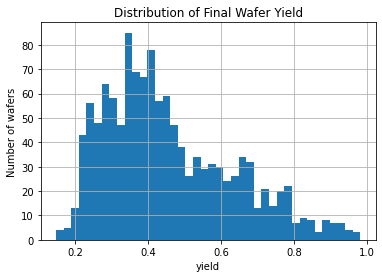

In [36]:
df[TARGET].hist(bins=40)

plt.xlabel(TARGET)
plt.ylabel("Number of wafers")
plt.title("Distribution of Final Wafer Yield")
plt.show()

## Within-Lot Variation
Confirm that continuous process and response variables vary among the 25 wafer observations nested within each lot.


In [37]:
# Check whether process variables vary within lots

process_variables = [
    "etch_rate",
    "pressure",
    "temperature",
    "exposure_time",
    "focus_offset",
    "dose",
    "deposition_rate",
    "thickness_uniformity",
    "implant_energy",
    "tilt_angle",
    "critical_dimension",
    "oxide_thickness",
    "resistivity",
    "defect_count",
    "defect_density",
    "vth",
    "leakage_current",
    "resistance",
    "yield"
]

within_lot_variation = []

for col in process_variables:
    unique_per_lot = df.groupby("lot_id")[col].nunique()

    within_lot_variation.append({
        "variable": col,
        "min_unique_per_lot": unique_per_lot.min(),
        "mean_unique_per_lot": unique_per_lot.mean(),
        "max_unique_per_lot": unique_per_lot.max(),
        "lots_with_variation": (unique_per_lot > 1).sum(),
        "pct_lots_with_variation": (unique_per_lot > 1).mean() * 100
    })

within_lot_variation = pd.DataFrame(within_lot_variation)

within_lot_variation

,variable,min_unique_per_lot,mean_unique_per_lot,max_unique_per_lot,lots_with_variation,pct_lots_with_variation
0,etch_rate,25,25.00,25,50,100.0
1,pressure,25,25.00,25,50,100.0
2,temperature,25,25.00,25,50,100.0
3,exposure_time,25,25.00,25,50,100.0
4,focus_offset,25,25.00,25,50,100.0
5,dose,25,25.00,25,50,100.0
6,deposition_rate,25,25.00,25,50,100.0
7,thickness_uniformity,25,25.00,25,50,100.0
8,implant_energy,25,25.00,25,50,100.0
9,tilt_angle,25,25.00,25,50,100.0


In [38]:
# Check within-lot variation in continuous variables

continuous_variables = [
    "etch_rate",
    "pressure",
    "temperature",
    "exposure_time",
    "focus_offset",
    "dose",
    "deposition_rate",
    "thickness_uniformity",
    "implant_energy",
    "tilt_angle",
    "critical_dimension",
    "oxide_thickness",
    "resistivity",
    "defect_density",
    "vth",
    "leakage_current",
    "resistance",
    "yield"
]

within_lot_std = (
    df.groupby("lot_id")[continuous_variables]
      .std()
      .describe()
      .T
)

within_lot_std

,count,mean,std,min,25%,50%,75%,max
etch_rate,50.0,7.812568e-02,1.143867e-02,5.942099e-02,6.904471e-02,7.649063e-02,8.430353e-02,1.091087e-01
pressure,50.0,4.851019e+00,7.725229e-01,2.916702e+00,4.380697e+00,4.923419e+00,5.370752e+00,6.478445e+00
temperature,50.0,1.957805e+00,3.062380e-01,1.358233e+00,1.824135e+00,1.956383e+00,2.151899e+00,2.578104e+00
exposure_time,50.0,4.940704e-02,7.244060e-03,3.371449e-02,4.468565e-02,4.896204e-02,5.226713e-02,7.298069e-02
focus_offset,50.0,4.960677e-03,6.918205e-04,3.623676e-03,4.411858e-03,5.027174e-03,5.463867e-03,6.403617e-03
dose,50.0,9.796292e+12,1.260540e+12,7.289801e+12,8.868037e+12,9.737996e+12,1.072932e+13,1.258599e+13
deposition_rate,50.0,1.003883e-01,1.457856e-02,5.287486e-02,9.260536e-02,1.003384e-01,1.082884e-01,1.363734e-01
thickness_uniformity,50.0,1.992887e-01,2.300347e-02,1.410431e-01,1.884153e-01,1.999776e-01,2.137031e-01,2.374641e-01
implant_energy,50.0,9.940428e-01,1.197192e-01,7.110304e-01,8.954523e-01,1.005642e+00,1.076326e+00,1.257253e+00
tilt_angle,50.0,4.953364e-01,7.191241e-02,3.392831e-01,4.389006e-01,4.919696e-01,5.528456e-01,6.397629e-01


In [39]:
example_lot = df["lot_id"].iloc[0]

example = (
    df[df["lot_id"] == example_lot]
    .sort_values("wafer_id")
)

example

,lot_id,wafer_id,product_type,technology_node,process_date,etch_tool,litho_tool,deposition_tool,implant_tool,etch_rate,pressure,temperature,exposure_time,focus_offset,dose,deposition_rate,thickness_uniformity,implant_energy,tilt_angle,critical_dimension,oxide_thickness,resistivity,defect_count,defect_density,vth,leakage_current,resistance,yield
0,LOT_0001,W001,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.559737,149.808678,66.595377,1.576151,0.019829,1.005426e+15,2.147921,1.673487,49.530526,6.768291,21.301405,55.604906,1.926016,664,0.946658,0.557038,0.000353,90.022492,0.678783
1,LOT_0001,W002,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.407016,147.352625,66.495441,1.627974,0.022971,1.002910e+15,1.938456,1.399949,50.947440,6.682220,20.467672,54.595612,2.339905,612,0.811460,0.585546,0.000122,103.656821,0.779966
2,LOT_0001,W003,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.413745,151.484306,66.776933,1.508568,0.020422,1.010571e+15,1.842148,1.376031,49.539361,7.171809,19.355440,55.810210,2.384475,584,0.798226,0.624927,0.000357,95.053771,0.778492
3,LOT_0001,W004,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.495263,142.959234,67.499294,1.491113,0.018948,9.896217e+14,1.900179,1.686959,50.296561,6.962098,23.459445,56.988989,2.948630,673,0.952954,0.646799,0.000250,105.176477,0.405275
4,LOT_0001,W005,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.526964,149.004963,65.483522,1.400622,0.019902,9.949824e+14,2.137789,1.416346,49.191506,7.457701,22.493127,53.675599,2.653980,613,0.818124,0.571641,0.000198,98.917061,0.935350
5,LOT_0001,W006,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.402919,137.224120,65.991036,1.480224,0.019554,9.905694e+14,1.973394,1.562988,47.977685,7.701979,21.972174,50.816238,2.178240,630,0.891271,0.559220,0.000343,93.395380,0.595224
6,LOT_0001,W007,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.517223,144.656610,67.585646,1.537597,0.024955,1.021905e+15,2.130279,1.239630,50.586857,6.504732,21.150553,55.249128,2.348957,529,0.732292,0.507202,0.000203,93.302619,0.922865
7,LOT_0001,W008,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.557887,153.602741,64.978125,1.480587,0.016572,1.013639e+15,2.045612,1.728772,50.526448,8.269581,21.513264,54.485333,2.067988,676,0.972672,0.671936,0.000433,101.507896,0.390799
8,LOT_0001,W009,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.543446,146.928243,69.031549,1.523692,0.015043,9.917932e+14,1.892532,1.677417,51.158596,7.481688,22.619171,57.055150,3.069038,628,0.946230,0.576339,0.000200,106.332446,0.891939
9,LOT_0001,W010,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.547292,156.546910,66.375920,1.636721,0.021469,1.000420e+15,1.986547,1.327397,50.977180,6.931364,21.813801,56.850852,2.364261,539,0.774433,0.634434,0.000134,97.003213,0.656926


In [40]:
example[
    [
        "lot_id",
        "wafer_id",
        "product_type",
        "technology_node",
        "litho_tool",
        "etch_tool",
        "deposition_tool",
        "implant_tool",
        "exposure_time",
        "pressure",
        "implant_energy",
        "critical_dimension",
        "defect_count",
        "vth",
        "yield"
    ]
]

,lot_id,wafer_id,product_type,technology_node,litho_tool,etch_tool,deposition_tool,implant_tool,exposure_time,pressure,implant_energy,critical_dimension,defect_count,vth,yield
0,LOT_0001,W001,CPU,10nm,LITHO_01,ETCH_02,DEP_03,IMP_01,1.576151,149.808678,49.530526,21.301405,664,0.557038,0.678783
1,LOT_0001,W002,CPU,10nm,LITHO_01,ETCH_02,DEP_03,IMP_01,1.627974,147.352625,50.947440,20.467672,612,0.585546,0.779966
2,LOT_0001,W003,CPU,10nm,LITHO_01,ETCH_02,DEP_03,IMP_01,1.508568,151.484306,49.539361,19.355440,584,0.624927,0.778492
3,LOT_0001,W004,CPU,10nm,LITHO_01,ETCH_02,DEP_03,IMP_01,1.491113,142.959234,50.296561,23.459445,673,0.646799,0.405275
4,LOT_0001,W005,CPU,10nm,LITHO_01,ETCH_02,DEP_03,IMP_01,1.400622,149.004963,49.191506,22.493127,613,0.571641,0.935350
5,LOT_0001,W006,CPU,10nm,LITHO_01,ETCH_02,DEP_03,IMP_01,1.480224,137.224120,47.977685,21.972174,630,0.559220,0.595224
6,LOT_0001,W007,CPU,10nm,LITHO_01,ETCH_02,DEP_03,IMP_01,1.537597,144.656610,50.586857,21.150553,529,0.507202,0.922865
7,LOT_0001,W008,CPU,10nm,LITHO_01,ETCH_02,DEP_03,IMP_01,1.480587,153.602741,50.526448,21.513264,676,0.671936,0.390799
8,LOT_0001,W009,CPU,10nm,LITHO_01,ETCH_02,DEP_03,IMP_01,1.523692,146.928243,51.158596,22.619171,628,0.576339,0.891939
9,LOT_0001,W010,CPU,10nm,LITHO_01,ETCH_02,DEP_03,IMP_01,1.636721,156.546910,50.977180,21.813801,539,0.634434,0.656926
